In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/Dataset"
!ls

/content/drive/MyDrive/Dataset
models	UNSW_NB15_testing-set.csv  UNSW_NB15_training-set.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [4]:
def load_data(file_path):
  data = pd.read_csv(file_path)
  return data

train_df = load_data("/content/drive/MyDrive/Dataset/UNSW_NB15_training-set.csv")
test_df = load_data("/content/drive/MyDrive/Dataset/UNSW_NB15_testing-set.csv")

def preprocess(train_df, test_df):
  excluded_cols = ["id", "label", "attack_cat"]

  train_features = train_df.drop(columns=excluded_cols)
  test_features = test_df.drop(columns=excluded_cols)

  categorical_cols = train_features.select_dtypes(include=["object"]).columns.tolist()

  train_labels_text = train_df["attack_cat"]
  test_labels_text = test_df["attack_cat"]

  label_encoder = LabelEncoder()
  train_labels = label_encoder.fit_transform(train_labels_text)
  test_labels = label_encoder.transform(test_labels_text)

  train_features_encoded = pd.get_dummies(train_features, columns=categorical_cols)
  test_features_encoded = pd.get_dummies(test_features, columns=categorical_cols)

  train_features_encoded, test_features_encoded = train_features_encoded.align(
      test_features_encoded,
      join="left",
      axis=1,
      fill_value=0
  )

  train_features_encoded = train_features_encoded.astype(float)
  test_features_encoded = test_features_encoded.astype(float)

  scaler = StandardScaler()
  train_features_scaled = scaler.fit_transform(train_features_encoded)
  test_features_scaled = scaler.transform(test_features_encoded)

  return train_features_scaled, train_labels, test_features_scaled, test_labels, label_encoder

82332
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


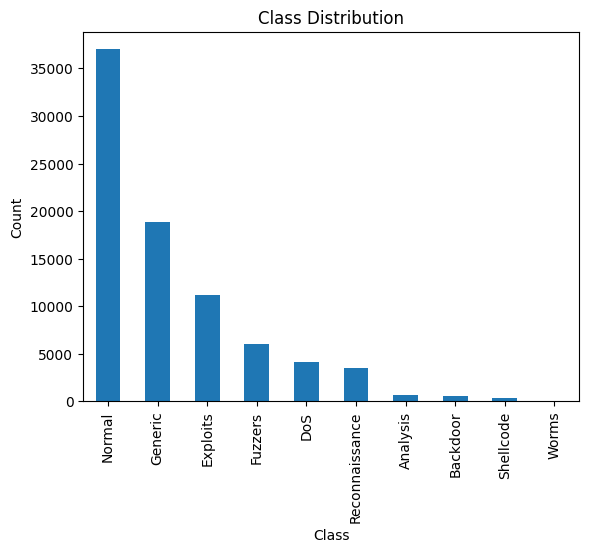

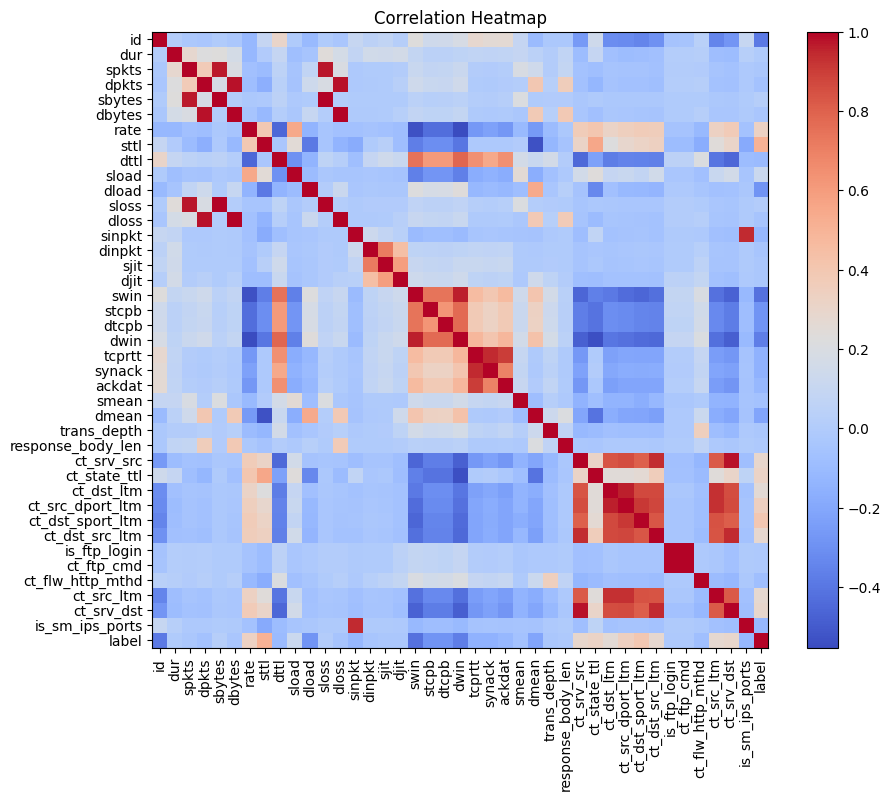

In [5]:
def dataset_info(df):
  print(len(df))
  print(df["attack_cat"].value_counts())

  df["attack_cat"].value_counts().plot(kind="bar")
  plt.title("Class Distribution")
  plt.xlabel("Class")
  plt.ylabel("Count")

  numeric_df = df.select_dtypes(include=np.number)
  corr_matrix = numeric_df.corr()
  plt.figure(figsize=(10, 8))
  plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest", )
  plt.colorbar()
  plt.title("Correlation Heatmap")
  plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
  plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

  plt.show()


dataset_info(train_df)

In [5]:
def calculate_class_weights(train_labels):
  classes = np.unique(train_labels)

  class_weights = compute_class_weight(
      class_weight="balanced",
      classes=classes,
      y=train_labels
  )

  class_weights = np.sqrt(class_weights)

  class_weights = np.minimum(class_weights, 5)

  class_weights_dict = dict(zip(classes, class_weights))

  return class_weights_dict

In [6]:
def create_validation_split(train_features_scaled, train_labels):
  return train_test_split(
      train_features_scaled,
      train_labels,
      test_size=0.2,
      random_state=42,
      stratify=train_labels
  )

In [9]:
def build_baseline_model(input_dim, num_classes):
  model = Sequential([
      Dense(64, activation="relu", input_shape=(input_dim,)),
      Dense(32, activation="relu"),
      Dense(16, activation="relu"),
      Dense(num_classes, activation="softmax")
  ])

  model.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["acc"]
  )

  model.summary()

  return model

In [10]:
def build_paper_dnn_model(input_dim, num_classes):
  model = Sequential([
      Dense(100, activation="relu", input_shape=(input_dim,)),
      Dense(100, activation="relu"),
      Dense(100, activation="relu"),
      Dense(num_classes, activation="softmax")
  ])

  model.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["acc"]
  )

  model.summary()

  return model

In [11]:
def build_paper_ann_model(input_dim, num_classes):
  model = Sequential([
      Input(shape=(input_dim,)),
      Dense(850, activation="relu"),
      Dense(num_classes, activation="softmax")
  ])

  model.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["acc"]
  )

  model.summary()

  return model

In [7]:
def build_dnn_lr(input_dim, num_classes):
  model = Sequential([
    Input(shape=(input_dim,)),

    Dense(100, activation="relu"),
    Dense(100, activation="relu"),
    Dense(100, activation="relu"),

    Dense(num_classes, activation="softmax")
  ])

  model.compile(
      optimizer = Adam(learning_rate=0.0005),
      loss="sparse_categorical_crossentropy",
      metrics=["acc"]
  )

  model.summary()

  return model

In [8]:
def save_model(experiment_name):
  checkpoint = ModelCheckpoint(filepath = f'/content/drive/MyDrive/Dataset/models/{experiment_name}/model.h5',
                             save_freq = "epoch",
                             verbose = 1)
  return checkpoint

In [9]:
def train_model(model, train_features_final, train_labels_final, validation_features, validation_labels, class_weights_dict, epochs, batch_size, checkpoint):
  history = model.fit(
      train_features_final,
      train_labels_final,
      epochs=epochs,
      batch_size=batch_size,
      validation_data=(validation_features, validation_labels),
      class_weight=class_weights_dict,
      callbacks=[checkpoint]
  )

  return history

In [10]:
def evaluate_model(history, model, test_features_scaled, test_labels):
  acc_train = history.history["acc"]
  loss_train = history.history["loss"]
  acc_val = history.history["val_acc"]
  loss_val = history.history["val_loss"]

  epochs = range(1, len(acc_train) + 1)

  plt.figure()
  plt.ylim(bottom=0)
  plt.plot(epochs, acc_train, "o-", color="blue", label="Train accuracy")
  plt.plot(epochs, acc_val, "s--", color="red", label="Val accuracy")
  plt.title("Train vs Validation Accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.legend()

  plt.figure()
  plt.ylim(bottom=0)
  plt.plot(epochs, loss_train, "o-", color="blue", label="Train loss")
  plt.plot(epochs, loss_val, "s--", color="red", label="Val loss")
  plt.title("Train vs Validation Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()

  plt.show()

  test_loss, test_accuracy = model.evaluate(test_features_scaled, test_labels)

  print("Test accuracy:", test_accuracy)
  print("Test loss:", test_loss)

In [11]:
def predict(model, test_features_scaled):
  predictions = model.predict(test_features_scaled)
  return predictions

def evaluate_predictions(predictions, test_labels, label_encoder):
  label_pred = np.argmax(predictions, axis=1)
  label_true = test_labels

  print("Classification Report:")
  print(classification_report(
      label_true,
      label_pred,
      target_names=label_encoder.classes_
  ))

  cm = confusion_matrix(label_true, label_pred)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal',
 'Reconnaissance', 'Shellcode', 'Worms'])

  disp.plot(cmap=plt.cm.Reds, xticks_rotation=90)
  plt.title("Confusion Matrix")
  plt.show()

In [12]:
def run_experiment(train_df, test_df, model_config, experiment_name, epochs, batch_size):
  print('='*40)
  print(f'Experiment: {experiment_name}')
  print('='*40)

  train_features_scaled, train_labels, test_features_scaled, test_labels, label_encoder = preprocess(train_df, test_df)
  train_features_final, validation_features, train_labels_final, validation_labels = create_validation_split(train_features_scaled, train_labels)
  class_weights_dict = calculate_class_weights(train_labels_final)

  input_dim = train_features_scaled.shape[1]
  num_classes = len(label_encoder.classes_)
  model = model_config(input_dim, num_classes)

  checkpoint = save_model(experiment_name)
  history = train_model(model, train_features_final, train_labels_final, validation_features, validation_labels, class_weights_dict, epochs, batch_size, checkpoint)
  evaluate_model(history, model, test_features_scaled, test_labels)
  predictions = predict(model, test_features_scaled)
  evaluate_predictions(predictions, test_labels, label_encoder)

  return model, history

Experiment: Baseline


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │        12,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,002 (58.60 KB)

...


Epoch 6: finished saving model to /content/drive/MyDrive/Dataset/models/Baseline/model.h5
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.8288 - loss: 0.5620 - val_acc: 0.8199 - val_loss: 0.4899
Epoch 7/10
1026/1030 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8289 - loss: 0.5479
Epoch 7: saving model to /content/drive/MyDrive/Dataset/models/Baseline/model.h5



Epoch 7: finished saving model to /content/drive/MyDrive/Dataset/models/Baseline/model.h5
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8303 - loss: 0.5508 - val_acc: 0.8385 - val_loss: 0.4465
Epoch 8/10
1021/1030 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8315 - loss: 0.5456
Epoch 8: saving model to /content/drive/MyDrive/Dataset/models/Baseline/model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/Dataset/models/Baseline/model.h5
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8336 - loss: 0.5416 - val_acc: 0.8360 - val_loss: 0.4491
Epoch 9/10
1006/1030 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8399 - loss: 0.5287
Epoch 9: saving model to /content/drive/MyDrive/Dataset/models/Baseline/model.h5



Epoch 9: finished saving model to /content/drive/MyDrive/Dataset/models/Baseline/model.h5
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8349 - loss: 0.5339 - val_acc: 0.8385 - val_loss: 0.4436
Epoch 10/10
1017/1030 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8350 - loss: 0.5322
Epoch 10: saving model to /content/drive/MyDrive/Dataset/models/Baseline/model.h5



Epoch 10: finished saving model to /content/drive/MyDrive/Dataset/models/Baseline/model.h5
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8355 - loss: 0.5278 - val_acc: 0.8340 - val_loss: 0.4428


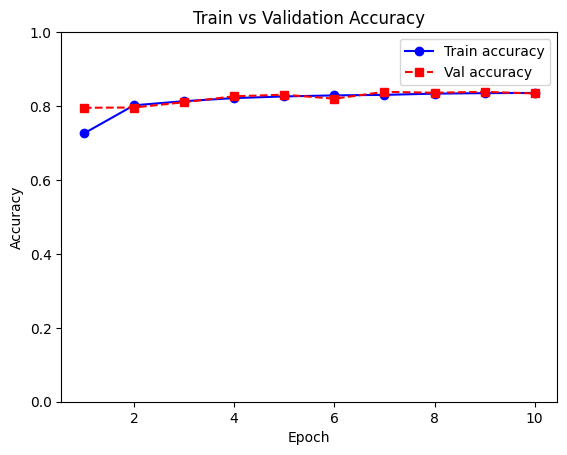

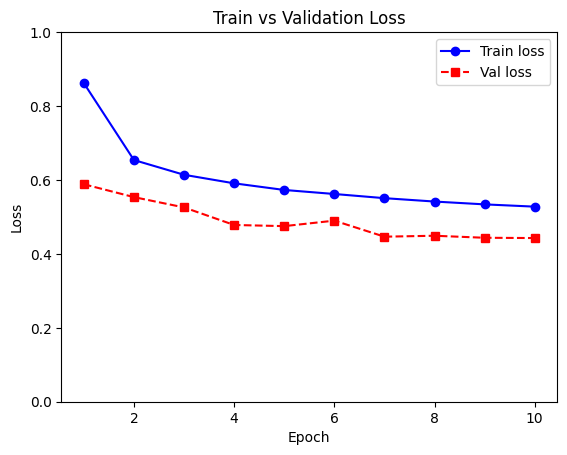

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - acc: 0.7422 - loss: 0.7071
Test accuracy: 0.7421994805335999
Test loss: 0.7070758938789368
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
Classification Report:
                precision    recall  f1-score   support

      Analysis       0.05      0.03      0.03      2000
      Backdoor       0.05      0.01      0.01      1746
           DoS       0.33      0.73      0.46     12264
      Exploits       0.80      0.51      0.62     33393
       Fuzzers       0.59      0.19      0.28     18184
       Generic       0.99      0.98      0.99     40000
        Normal       0.77      0.96      0.86     56000
Reconnaissance       0.72      0.70      0.71     10491
     Shellcode       0.43      0.36      0.39      1133
         Worms       0.59      0.15      0.24       130

      accuracy                           0.74    175341
     macro avg       0.53      0.46      0.46    175341
  weighted avg       0.76      0.74      0.72    175341



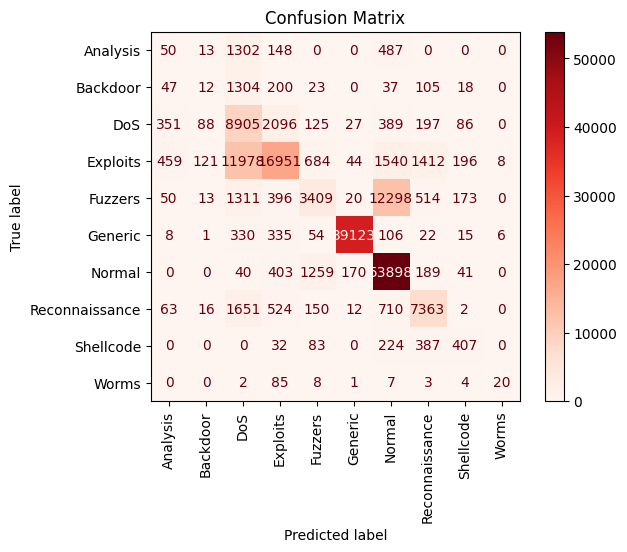

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Sample index: 777
True label: Normal
Predicted label: Normal
Confidence: 0.9999846
Correct prediction: True

Original sample data:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
777,778,1.648349,tcp,-,FIN,16,18,1540,1644,20.020032,...,1,5,0,0,0,7,11,0,Normal,0



Prediction probabilities:


,Class,Probability
6,Normal,9.999846e-01
2,DoS,7.820952e-06
3,Exploits,7.151568e-06
5,Generic,3.611839e-07
8,Shellcode,7.606522e-09
4,Fuzzers,8.553739e-10
0,Analysis,8.221815e-10
1,Backdoor,1.871067e-11
9,Worms,1.446279e-11
7,Reconnaissance,6.345509e-12


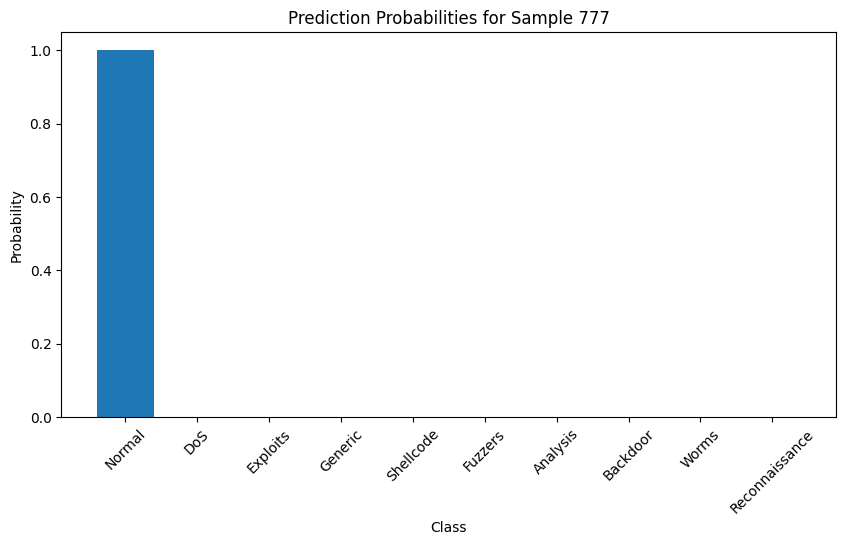

(<Sequential name=sequential_4, built=True>,
 <keras.src.callbacks.history.History at 0x7b2e74a4e4b0>)

In [29]:
# baseline model
run_experiment(train_df, test_df, build_baseline_model, "Baseline", 10, 64)

Experiment: Paper based DNN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 100)            │        19,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,310 (157.46 KB)

...


Epoch 96: finished saving model to /content/drive/MyDrive/Dataset/models/Paper based DNN/model.h5
659/659 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.8750 - loss: 0.3537 - val_acc: 0.8536 - val_loss: 0.4240
Epoch 97/100
650/659 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8781 - loss: 0.3455
Epoch 97: saving model to /content/drive/MyDrive/Dataset/models/Paper based DNN/model.h5



Epoch 97: finished saving model to /content/drive/MyDrive/Dataset/models/Paper based DNN/model.h5
659/659 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8760 - loss: 0.3517 - val_acc: 0.8439 - val_loss: 0.4542
Epoch 98/100
655/659 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8761 - loss: 0.3494
Epoch 98: saving model to /content/drive/MyDrive/Dataset/models/Paper based DNN/model.h5



Epoch 98: finished saving model to /content/drive/MyDrive/Dataset/models/Paper based DNN/model.h5
659/659 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.8746 - loss: 0.3535 - val_acc: 0.8522 - val_loss: 0.4251
Epoch 99/100
656/659 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8755 - loss: 0.3512
Epoch 99: saving model to /content/drive/MyDrive/Dataset/models/Paper based DNN/model.h5



Epoch 99: finished saving model to /content/drive/MyDrive/Dataset/models/Paper based DNN/model.h5
659/659 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8734 - loss: 0.3587 - val_acc: 0.8349 - val_loss: 0.4695
Epoch 100/100
650/659 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.8722 - loss: 0.3593
Epoch 100: saving model to /content/drive/MyDrive/Dataset/models/Paper based DNN/model.h5



Epoch 100: finished saving model to /content/drive/MyDrive/Dataset/models/Paper based DNN/model.h5
659/659 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8733 - loss: 0.3567 - val_acc: 0.8501 - val_loss: 0.4375


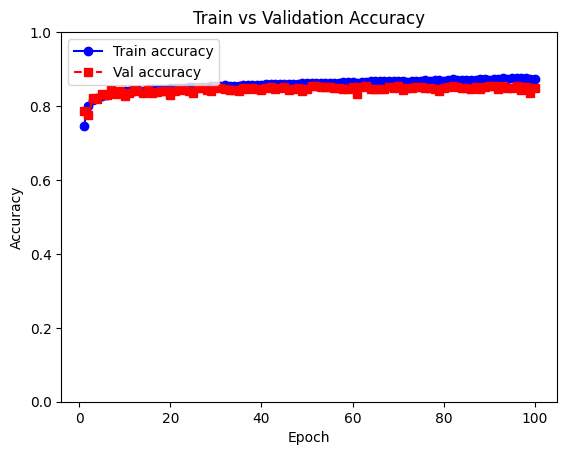

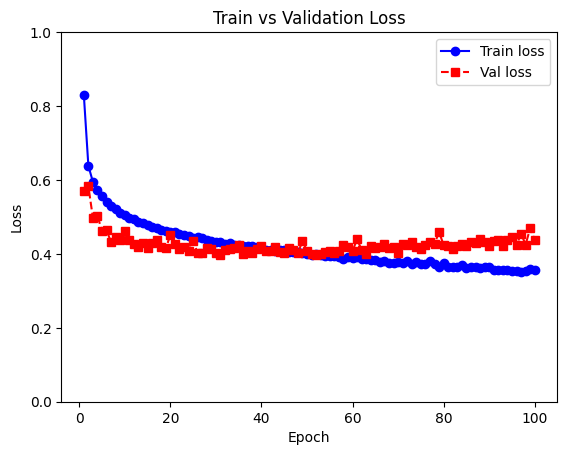

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - acc: 0.7432 - loss: 1.1685
Test accuracy: 0.7431519031524658
Test loss: 1.1684664487838745
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Classification Report:
                precision    recall  f1-score   support

      Analysis       0.04      0.01      0.02      2000
      Backdoor       0.07      0.08      0.07      1746
           DoS       0.32      0.76      0.45     12264
      Exploits       0.83      0.49      0.61     33393
       Fuzzers       0.67      0.18      0.28     18184
       Generic       0.98      0.98      0.98     40000
        Normal       0.78      0.96      0.86     56000
Reconnaissance       0.81      0.72      0.76     10491
     Shellcode       0.58      0.48      0.52      1133
         Worms       0.19      0.25      0.21       130

      accuracy                           0.74    175341
     macro avg       0.53      0.49      0.48    175341
  weighted avg       0.78      0.74      0.73    175341



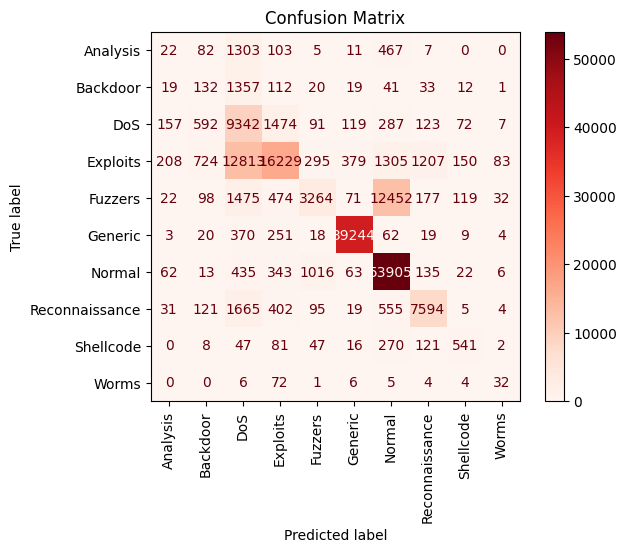

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Sample index: 777
True label: Normal
Predicted label: Normal
Confidence: 1.0
Correct prediction: True

Original sample data:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
777,778,1.648349,tcp,-,FIN,16,18,1540,1644,20.020032,...,1,5,0,0,0,7,11,0,Normal,0



Prediction probabilities:


,Class,Probability
6,Normal,1.000000e+00
3,Exploits,7.024943e-29
2,DoS,4.521775e-35
0,Analysis,0.000000e+00
1,Backdoor,0.000000e+00
4,Fuzzers,0.000000e+00
5,Generic,0.000000e+00
7,Reconnaissance,0.000000e+00
8,Shellcode,0.000000e+00
9,Worms,0.000000e+00


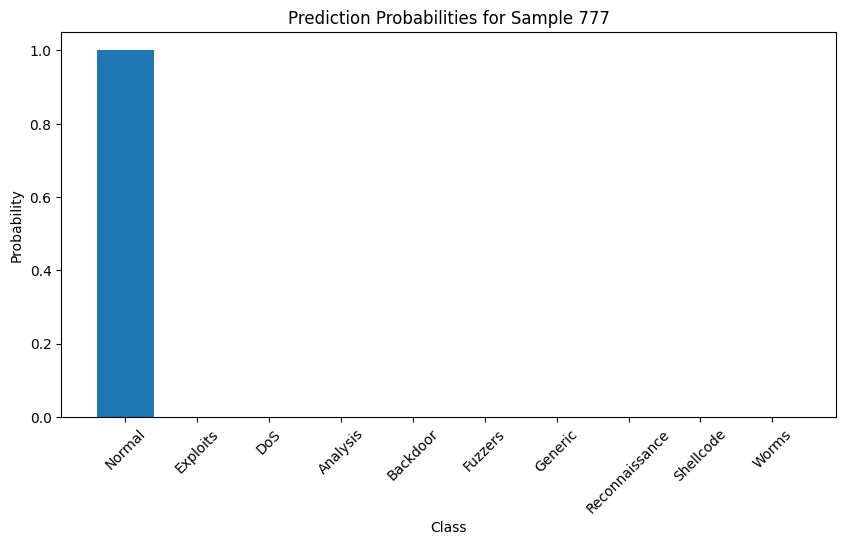

(<Sequential name=sequential_5, built=True>,
 <keras.src.callbacks.history.History at 0x7b2e74b4c950>)

In [30]:
# Paper DNN based model
#run_experiment(train_df, test_df)
run_experiment(train_df, test_df, build_paper_dnn_model, "Paper based DNN", 100, 100)

Experiment: Paper based ANN


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 850)            │       162,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         8,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 170,860 (667.42 KB)

 Trainable params: 170,860 (667.42 KB)

...


Epoch 96: finished saving model to /content/drive/MyDrive/Dataset/models/Paper based ANN/model.h5
659/659 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - acc: 0.8596 - loss: 0.4391 - val_acc: 0.8427 - val_loss: 0.4618
Epoch 97/100
655/659 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.8608 - loss: 0.4322
Epoch 97: saving model to /content/drive/MyDrive/Dataset/models/Paper based ANN/model.h5



Epoch 97: finished saving model to /content/drive/MyDrive/Dataset/models/Paper based ANN/model.h5
659/659 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8602 - loss: 0.4377 - val_acc: 0.8510 - val_loss: 0.4478
Epoch 98/100
658/659 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.8608 - loss: 0.4294
Epoch 98: saving model to /content/drive/MyDrive/Dataset/models/Paper based ANN/model.h5



Epoch 98: finished saving model to /content/drive/MyDrive/Dataset/models/Paper based ANN/model.h5
659/659 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8594 - loss: 0.4395 - val_acc: 0.8478 - val_loss: 0.4418
Epoch 99/100
658/659 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.8587 - loss: 0.4299
Epoch 99: saving model to /content/drive/MyDrive/Dataset/models/Paper based ANN/model.h5



Epoch 99: finished saving model to /content/drive/MyDrive/Dataset/models/Paper based ANN/model.h5
659/659 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - acc: 0.8594 - loss: 0.4338 - val_acc: 0.8479 - val_loss: 0.4502
Epoch 100/100
655/659 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.8575 - loss: 0.4373
Epoch 100: saving model to /content/drive/MyDrive/Dataset/models/Paper based ANN/model.h5



Epoch 100: finished saving model to /content/drive/MyDrive/Dataset/models/Paper based ANN/model.h5
659/659 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8593 - loss: 0.4330 - val_acc: 0.8476 - val_loss: 0.4517


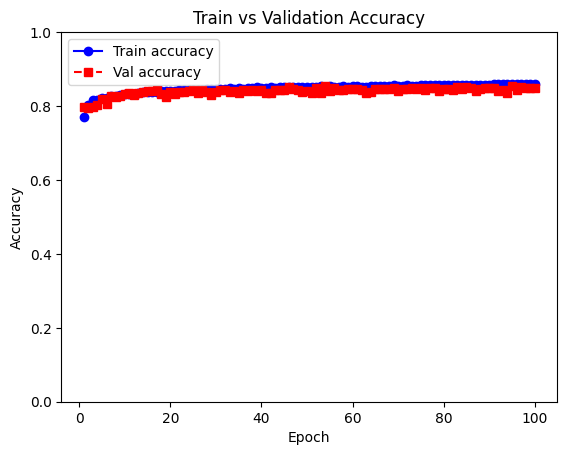

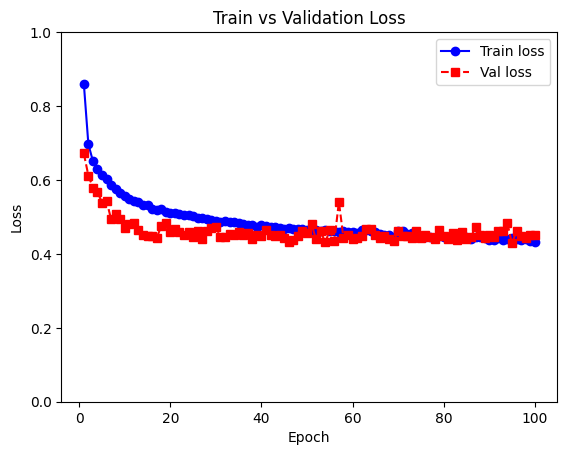

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - acc: 0.7372 - loss: 1.2446
Test accuracy: 0.7371749877929688
Test loss: 1.2445955276489258
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Classification Report:
                precision    recall  f1-score   support

      Analysis       0.05      0.01      0.01      2000
      Backdoor       0.09      0.04      0.06      1746
           DoS       0.33      0.72      0.45     12264
      Exploits       0.81      0.47      0.59     33393
       Fuzzers       0.61      0.14      0.23     18184
       Generic       0.97      0.98      0.98     40000
        Normal       0.77      0.97      0.86     56000
Reconnaissance       0.74      0.75      0.74     10491
     Shellcode       0.44      0.61      0.51      1133
         Worms       0.09      0.32      0.14       130

      accuracy                           0.74    175341
     macro avg       0.49      0.50      0.46    175341
  weighted avg       0.76      0.74      0.71    175341



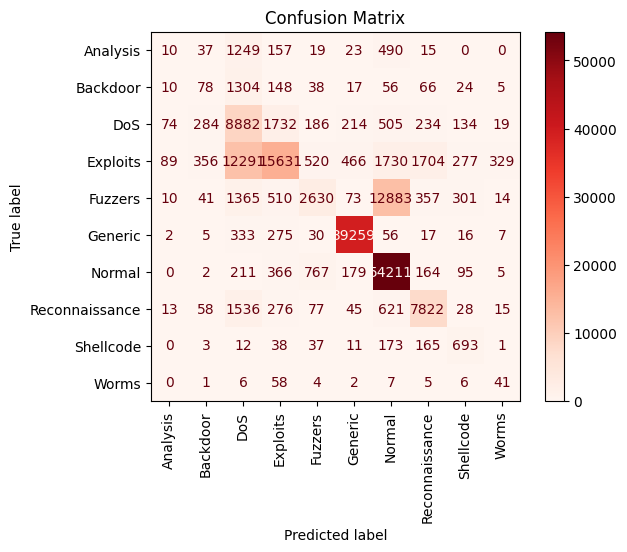

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Sample index: 777
True label: Normal
Predicted label: Normal
Confidence: 1.0
Correct prediction: True

Original sample data:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
777,778,1.648349,tcp,-,FIN,16,18,1540,1644,20.020032,...,1,5,0,0,0,7,11,0,Normal,0



Prediction probabilities:


,Class,Probability
6,Normal,1.000000e+00
2,DoS,1.709085e-21
3,Exploits,9.777151e-23
1,Backdoor,4.932472e-23
0,Analysis,3.205764e-24
4,Fuzzers,1.929466e-27
5,Generic,1.156659e-27
7,Reconnaissance,5.070662e-28
8,Shellcode,0.000000e+00
9,Worms,0.000000e+00


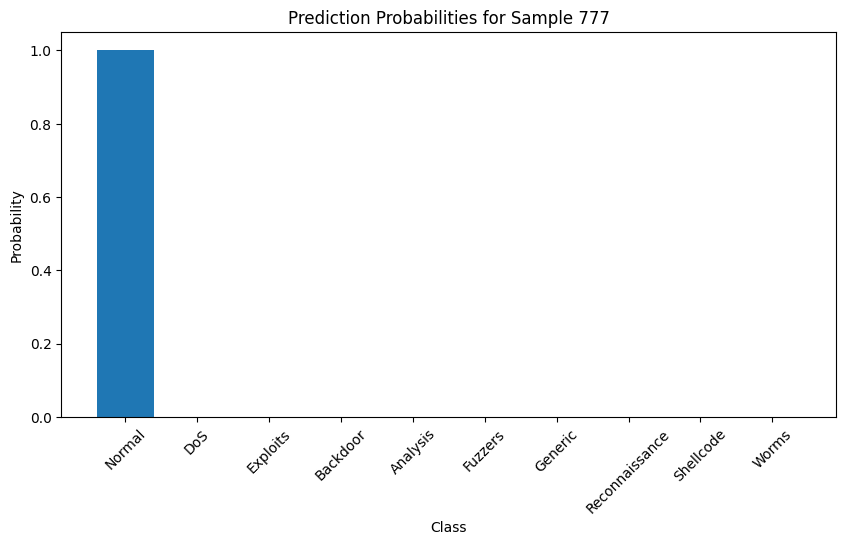

(<Sequential name=sequential_6, built=True>,
 <keras.src.callbacks.history.History at 0x7b2e85889ee0>)

In [31]:
# Paper ANN based model
run_experiment(train_df, test_df, build_paper_ann_model, "Paper based ANN", 100, 100)

Model loaded successfully.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        19,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,932 (472.39 KB)

 Trainable params: 40,310 (157.46 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 80,622 (314.93 KB)


Data prepared correctly.
Train features: (82332, 190)
Test features: (175341, 190)
Classes: ['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - acc: 0.7493 - loss: 0.9033

Final Tuned DNN Model Results
-----------------------------
Test accuracy: 0.7492828369140625
Test loss: 0.9033213257789612
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step

Classification Report:
                precision    recall  f1-score   support

      Analysis       0.05      0.01      0.02      2000
      Backdoor       0.06      0.06      0.06      1746
           DoS       0.33      0.77      0.46     12264
      Exploits       0.83      0.49      0.62     33393
       Fuzzers       0.65      0.22      0.33     18184
       Generic       0.99      0.98      0.98     40000
        Normal       0.79      0.95      0.87     56000
Reconnaissance       0.79      0.76      0.78     10491
     Shellcode       0.48    

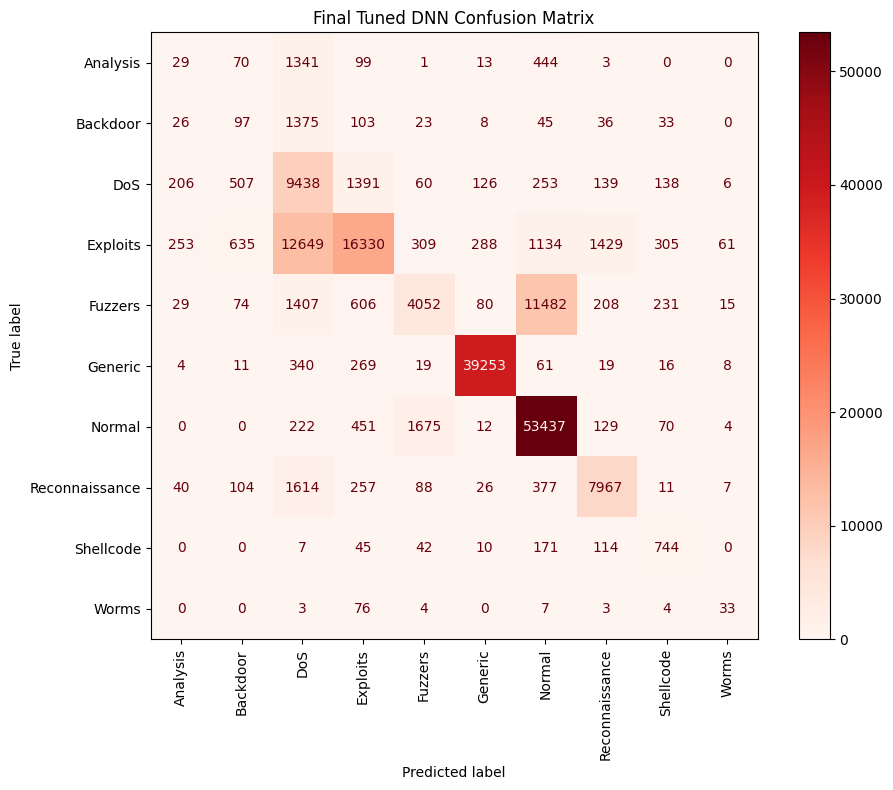

In [14]:
# final DNN with LR=0.0005 and capped weights (trained locally)
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

MODEL_PATH = "/content/drive/MyDrive/Dataset/models/DNN_LR_CapWeights/model.keras"
final_model = load_model(MODEL_PATH)

print("Model loaded successfully.\n")
final_model.summary()

train_features_scaled, train_labels, test_features_scaled, test_labels, label_encoder = preprocess(train_df, test_df)

print("\nData prepared correctly.")
print("Train features:", train_features_scaled.shape)
print("Test features:", test_features_scaled.shape)
print("Classes:", label_encoder.classes_)

test_loss, test_accuracy = final_model.evaluate(test_features_scaled, test_labels)

print("\nFinal Tuned DNN Model Results")
print("-----------------------------")
print(f"Test accuracy: {test_accuracy}")
print(f"Test loss: {test_loss}")

predictions = final_model.predict(test_features_scaled)
predicted_labels = np.argmax(predictions, axis=1)

print("\nClassification Report:")
print(
    classification_report(
        test_labels,
        predicted_labels,
        target_names=label_encoder.classes_
    )
)

cm = confusion_matrix(test_labels, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    cmap=plt.cm.Reds,
    xticks_rotation=90,
    ax=ax,
    colorbar=True
)

plt.title("Final Tuned DNN Confusion Matrix")
plt.tight_layout()
plt.show()